# Boosting

**Boosting**: méthode d'apprentissage supervisé conçue pour transformer des modèles simples en modèles performants. Au lieu de chercher à construire un seul modèle complexe et parfait d'un coup, on assemble une multitude de modèles très simples (les "apprenants faibles") qui se corrigent les uns les autres.  
Un **apprenant faible** est un modèle dont la performance est juste au-dessus du hasard (une erreur légèrement inférieure à 50% pour un problème binaire).  
Contrairement à d'autres méthodes (comme le Bagging/Random Forest) où les modèles sont créés en parallèle, le Boosting crée les modèles les uns après les autres:
1) On entraîne un premier modèle simple sur les données. Il fait forcément des erreurs.
2) On analyse ses erreurs. On demande au deuxième modèle simple de se concentrer prioritairement sur les exemples que le premier a ratés.
3) On recommence. Le troisième modèle s'attaque aux erreurs restantes du duo précédent, et ainsi de suite.

Il existe deux stratégies pour forcer le modèle suivant à s'améliorer:
- Par les Poids (AdaBoost = Adaptative Boosting)
- Par les Résidus (Gradient Boosting)

### AdaBoost
Conçu pour la classification binaire ($y \in \{-1, 1\}$).  
Son principe repose sur la transformation d'un apprenant faible en un modèle robuste par un processus itératif et pondéré. 
On utilise généralement des Decision Stumps (des arbres de décision à un seul niveau).

L'algorithme cherche à minimiser la perte exponentielle:
$$l(y, h(x)) = e^{-yh(x)}$$
À chaque itération $k$, on ajoute un nouveau modèle $h_k$ pour réduire cette perte globale.

Pour $L$ itérations prévues:

Initialisation: Chaque instance de l'ensemble d'entraînement reçoit un poids identique $w_i^{(1)} = 1/n$ car on considrèe que toutes les données ont la même importance.  
Apprentissage du modèle : On entraîne un classificateur faible $h_k$  qui minimise l'erreur pondérée.  
Calcul de l'erreur ($\hat{\epsilon}_k$): On somme les poids des instances mal classées : $\hat{\epsilon}_k = \sum_{y_i \neq h_k(x_i)} w_i^{(k)}$.  
Calcul de la confiance ($\alpha_k$): On détermine l'importance du modèle dans le vote final:
$$\alpha_k = \frac{1}{2} \ln\left(\frac{1-\hat{\epsilon}_k}{\hat{\epsilon}_k}\right)$$
Plus il fait d'erreurs, moins sa voix comptera dans la décision finale.  
Mise à jour des poids ($w_i^{(k+1)}$): Les poids sont ajustés pour l'itération suivante:  
   - Augmentation du poids si $h_k(x_i) \neq y_i$ (erreur).
   - Diminution du poids si $h_k(x_i) = y_i$ (succès).

Prédiction finale:
Le modèle global $H_L(x)$ est une combinaison linéaire de tous les modèles faibles, pondérée par leur score de confiance $\alpha_k$:
$$H_L(x) = \text{sign}\left(\sum_{k=1}^L \alpha_k h_k(x)\right)$$

Avantanges:
- Réduction du bias, c'est à dire l'erreur systématique du modèle. En se concentrant sur les exemples difficiles, il finit par "comprendre" des motifs complexes que la Random Forest pourrait lisser ou ignorer.
- Adaptabilité: Il s'ajuste dynamiquement à la difficulté des données.

Limites:
* Complexité: Si $L$ est trop grand par rapport au nombre d'échantillons $n$, il existe un risque théorique de sur-apprentissage.
* Robustesse: En pratique, le sur-apprentissage est rare car le modèle devient de plus en plus confiant (maximisation de la marge).
* Paramètres: On utilise généralement des arbres très simples (profondeur 1 à 3) pour conserver le caractère "faible" de l'apprenant.

**Mécanisme itératif**:

1. On entraîne un premier "Decision Stump" (arbre à une seule question) sur les données où chaque point a la même importance.
2. On repère les erreurs. On "gonfle" l'importance des données mal classées.
3. On entraîne un deuxième "Stump". Celui-ci va se focaliser sur les points "gonflés" pour corriger le tir.
4. En répétant cela, on obtient une suite de modèles très simples qui, mis bout à bout, finissent par comprendre les subtilités complexes des données.

### Gradient Boosting

Le Gradient Boosting ne change pas le poids des données mais ajuste la cible à prédire à chaque étape. Il repose sur l'idée que chaque nouvel arbre doit corriger l'erreur résiduelle laissée par l'ensemble des arbres précédents.

1. Initialisation ($H_0$): On commence par une constante minimisant la perte globale (ex: moyenne des cibles).
2. Calcul du Résidu ($\tilde{y}_i$): On calcule l'écart entre la réalité et la prédiction actuelle (gradient négatif de la perte $l$).
3. Apprentissage ($h_k$): On entraîne un arbre de régression pour prédire ces résidus, même en classification.
4. Mise à jour pondérée: On ajoute cette correction au modèle avec un taux d'apprentissage $\eta$ : $H_k(x) = H_{k-1}(x) + \eta h_k(x)$.
5. Convergence: On itère $L$ fois. Plus $\eta$ est petit, plus $L$ doit être grand.

Avantages:   
- Versatilité: Cette approche permet de traiter aussi bien des problèmes de régression (perte $l(y,h) = (y-h)^2$) que de classification (perte logistique) en changeant simplement la fonction de perte
- Performance: Excellent pour les d onnées tabulaires.
- Précision: Généralement bien plus précis et polyvalent qu'AdaBoost.

Limites:
- Réglage des hyper-paramètres particulièrement complexe
- Risque de sur-apprentissage si le nombre d'itérations $L$ est trop grand ou si $\eta$ n'est pas assez petit
- Complexité: Demande plus de ressources en calcul et en mémoire

## 1 - Multiclass classification with Boosting

D'abord, on va s'intéresser à un dataset sur lequel on va diviser nos données en données de train et données de test. Le but ensuite est d'entraîner 3 modèles sur ces données, dont 2 modèles de Boosting, et de compareur leurs résultats et temps d'exécution.

In [8]:
from sklearn.datasets import fetch_covtype
X, y = fetch_covtype(return_X_y=True, as_frame=False)

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.5, stratify=y)

In [10]:
from sklearn.ensemble import AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=3), 
                        n_estimators=100)

In [11]:
hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=5)

In [12]:
from sklearn.ensemble import RandomForestClassifier
forest = RandomForestClassifier(n_estimators=100)

**HistGradientBoostingClassifier**

In [14]:
from sklearn.metrics import accuracy_score
import time 
start = time.time()
hgb.fit(X_train, Y_train)
score_test_hgb = accuracy_score(Y_test, hgb.predict(X_test))
stop = time.time()
print(f"time: {stop-start}s")
print(f"score de test: {100*score_test_hgb:.4f}%")

time: 6.680456876754761s
score de test: 80.1612%


**AdaBoostClassifier**

In [16]:
start = time.time()
clf.fit(X_train, Y_train)
score_test_clf = accuracy_score(Y_test, clf.predict(X_test))
stop = time.time()
print(f"time: {stop-start}s")
print(f"score de test: {100*score_test_clf:.4f}%")

time: 64.13178730010986s
score de test: 59.9667%


**RandomForestClassifier**

In [17]:
start = time.time()
forest.fit(X_train, Y_train)
score_test_forest = accuracy_score(Y_test, forest.predict(X_test))
stop = time.time()
print(f"time: {stop-start}s")
print(f"score de test: {100*score_test_forest:.4f}%")

time: 34.101985454559326s
score de test: 94.4679%


Le modèle HistGradientBoosting s’avère rapide et donne des résultats satisfaisants. Pour ce jeu de données, le meilleur modèle est le RandomForest, car il entraîne les données en un temps raisonnable tout en obtenant un faible taux d’erreur de prédiction (~5 %).  

Concernant le modèle AdaBoost, ses performances varient fortement selon la complexité des apprenants faibles utilisés:
- Avec une profondeur d'arbre de 3, le score est d'environ 60%
- Ce résultat reste modeste mais cohérent, car AdaBoost a été initialement conçu pour la classification binaire. Pour ce problème à 7 classes, une variante comme AdaBoost.SAMME est nécessaire pour maintenir l'efficacité.
On pourrait augmenter la profondeur des arbres de AdaBoost pour augmenter le score mais en retour:
- temps d'exécution beaucoup trop long en raison de la nature séquentielle du Boosting
- risque accru d'overfitting

Les résultats pour la Random Forest sont excellents.

## 2 - Depth of decision trees in Adaboost and Gradient Boosting

L'objectif désormais est de comparer les taux d'erreur obtenus par les deux modèles de Boosting en fonction dde la profondeur des arbres de décision. On testera ces deux modèles sur deux datasets.

In [51]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OrdinalEncoder
X,y = fetch_openml("car-evaluation", return_X_y=True, as_frame=False)
enc = OrdinalEncoder()
X_encoded = enc.fit_transform(X)

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X_encoded,y, 
                                    test_size=0.5, stratify=y)

In [53]:
import numpy as np

max_depth = 15
depths = np.arange(1, max_depth + 1)
err_test = np.zeros(len(depths))

for ind, depth in enumerate(depths):
    clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=depth), 
                            n_estimators=100)
    clf.fit(X_train, Y_train)
    score_test_clf = accuracy_score(Y_test, clf.predict(X_test))
    err_test[ind] = 1-score_test_clf

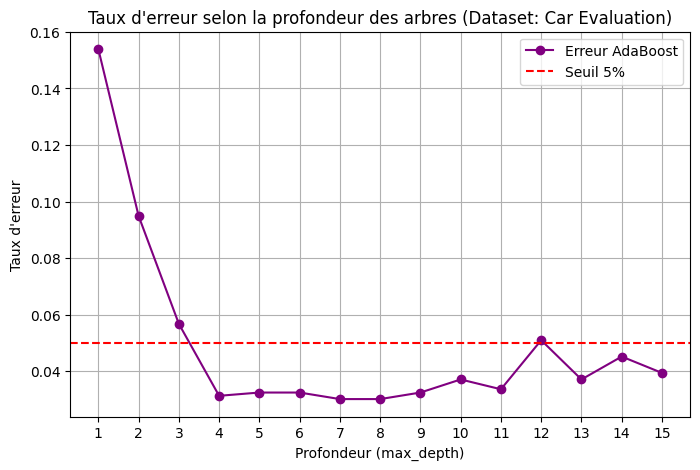

In [54]:
plt.figure(figsize=(8, 5))
plt.plot(depths, err_test, '-o', color='purple', label="Erreur AdaBoost")
plt.axhline(y=0.05, color='red', linestyle='--', label="Seuil 5%")
plt.title("Taux d'erreur selon la profondeur des arbres (Dataset: Car Evaluation)")
plt.xlabel("Profondeur (max_depth)")
plt.ylabel("Taux d'erreur")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

In [60]:
print(err_test)

[0.15393519 0.09490741 0.05671296 0.03125    0.03240741 0.03240741
 0.03009259 0.03009259 0.03240741 0.03703704 0.03356481 0.05092593
 0.03703704 0.04513889 0.03935185]


In [65]:
ind_min = err_test.argmin()
depthOpt = depths[ind_min]
print(f"\n Optimal depth = {depthOpt}, erreur de {100*err_test[ind_min]:.4f}%")


 Optimal depth = 7, erreur de 3.0093%


De la profondeur 1 à 4, l'erreur chute drastiquement de $15,3\%$ à $3,1\%$. Cela montre comment le Boosting transforme des apprenants très faibles en un modèle fort.  
Stagnation et instabilité : Entre la profondeur 7 et 15, l'erreur ne diminue plus vraiment et remonte même parfois (ex: $5,09\%$ à la profondeur 12). C'est le signe d'un début de sur-apprentissage (overfitting).  
Complexité inutile: Les arbres profonds ont tendance à sur-apprendre. Ici, la profondeur 7 est "optimale" sur ce test, mais une profondeur de 4 donne déjà un résultat quasiment identique ($3,12\%$) avec un modèle beaucoup plus simple et rapide.

In [66]:
erreurs_hgb = []
depths = np.arange(1,16)
max_depth = 15
for depth in range(1,max_depth+1):
    hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=depth)
    hgb.fit(X_train, Y_train)
    score_test_hgb = accuracy_score(Y_test, hgb.predict(X_test))
    erreurs_hgb.append(1-score_test_hgb)

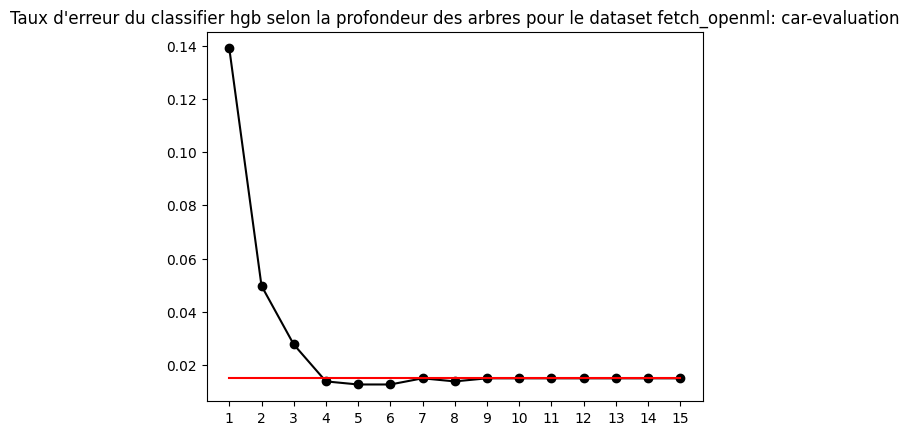

In [67]:
import matplotlib.pyplot as plt
plt.plot(depths, erreurs_hgb, '-o', c='black')
plt.plot([1,15], [0.015,0.015], c='red')
plt.title("Taux d'erreur du classifier hgb selon la profondeur des arbres pour le dataset fetch_openml: car-evaluation")
plt.xticks(np.arange(1,16))
plt.show()

In [75]:
erreurs_hgb_np = np.array(erreurs_hgb)
ind_min = erreurs_hgb_np.argmin()
depthOpt = depths[ind_min]
print(f"\n Optimal depth = {depthOpt}, erreur de {100*erreurs_hgb_np[ind_min]:.4f}%")


 Optimal depth = 5, erreur de 1.2731%


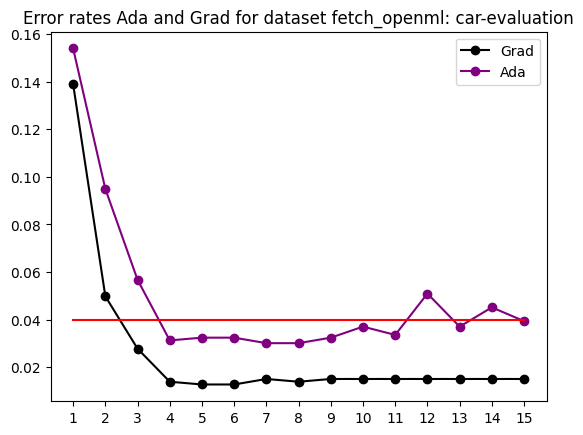

In [76]:
import matplotlib.pyplot as plt
plt.plot(depths, erreurs_hgb, '-o', label="Grad", c='black')
plt.plot(depths, err_test, '-o', label="Ada", c='purple')
plt.plot([1,15], [0.04,0.04], c='red')
plt.xticks(np.arange(1,16))
plt.title("Error rates Ada and Grad for dataset fetch_openml: car-evaluation")
plt.legend()
plt.show()

Le graphique confirme les résultats théoriques : le Gradient Boosting (noir) surpasse AdaBoost (violet) en termes de précision et de stabilité. On observe également qu'AdaBoost devient instable avec des arbres trop profonds (risque d'overfitting), alors que le Gradient Boosting maintient une erreur faible et constante, prouvant sa robustesse sur les données tabulaires.

In [110]:
from sklearn.datasets import load_breast_cancer

In [111]:
X, y = load_breast_cancer(return_X_y=True)

In [112]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.5, stratify=y)

In [113]:
max_depth = 15
depths = np.arange(1, max_depth + 1)
err_test = np.zeros(len(depths))

for ind, depth in enumerate(depths):
    clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=depth), 
                            n_estimators=100)
    clf.fit(X_train, Y_train)
    score_test_clf = accuracy_score(Y_test, clf.predict(X_test))
    err_test[ind] = 1-score_test_clf

In [114]:
erreurs_hgb = []
for depth in depths:
    hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=depth)
    hgb.fit(X_train, Y_train)
    score_test_hgb = accuracy_score(Y_test, hgb.predict(X_test))
    erreurs_hgb.append(1-score_test_hgb)

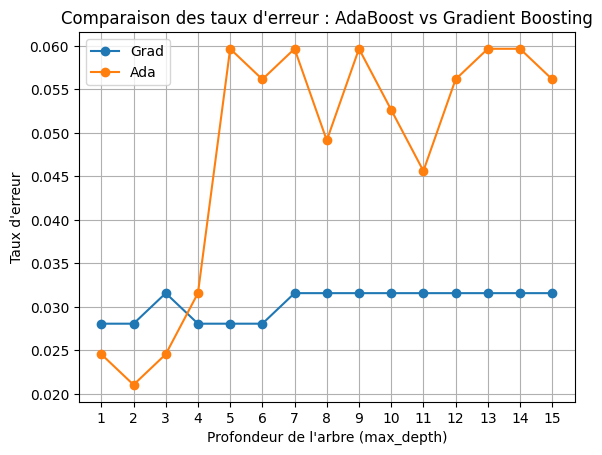

In [115]:
plt.plot(depths, erreurs_hgb, '-o', label="Grad")
plt.plot(depths, err_test, '-o', label="Ada")
plt.xticks(depths)
plt.title("Comparaison des taux d'erreur : AdaBoost vs Gradient Boosting")
plt.xlabel("Profondeur de l'arbre (max_depth)")
plt.ylabel("Taux d'erreur")
plt.legend()
plt.grid()
plt.show()

In [116]:
erreurs_hgb_np = np.array(erreurs_hgb)
ind_min = erreurs_hgb_np.argmin()
depthOpt = depths[ind_min]
print(f"\n Optimal depth = {depthOpt}, erreur de {100*erreurs_hgb_np[ind_min]:.4f}%")


 Optimal depth = 1, erreur de 2.8070%


In [117]:
ind_min = err_test.argmin()
depthOpt = depths[ind_min]
print(f"\n Optimal depth = {depthOpt}, erreur de {100*err_test[ind_min]:.4f}%")


 Optimal depth = 2, erreur de 2.1053%


On observe que pour ce dataset, le modèle AdaBoost explose rapidement en erreur lorsque la profondeur des arbres augmente, pour atteindre un taux d'erreur d'environ 10%. Donc ce modèle semble très sensible au bruit et à sur-apprendre rapidement.  

Le modèle Grad quant à lui est ultra stable à partir d'une certaine profondeur, le modèle est plus robuste et donne un bien meilleur score.

En conclusion, Grad surclasse clairement AdaBoost sur ce dataset.
AdaBoost devient instable et surapprend, alors que Grad reste stable et performant. Mais AdaBoost obtient tout de même le meilleur résultat overall.

## 3 - Gradient Boosting: learning rate versus number of trees

Enfin, on s'interesse exclusivement au modèle de Gradient Boosting et à l'évolution de ses performances de prédiction en fonction du nombre d'arbres.

In [141]:
from sklearn.datasets import fetch_california_housing
X,y = fetch_california_housing(return_X_y=True, as_frame=True)
n_samples, n_features = X.shape
print(f"number of samples: {n_samples}, number of features: {n_features}")

number of samples: 20640, number of features: 8


In [142]:
X_train, X_test, Y_train, Y_test = train_test_split(X,y, 
                                    test_size=0.2)

In [143]:
# affiche tous les paramètres de scoring possible
from sklearn.metrics import get_scorer_names
# get_scorer_names()

**Learning Rate ($\eta$)**: vitesse à laquelle le modèle apprend des erreurs précédentes. Dans le Boosting, on ne corrige pas l'erreur à 100% d'un seul coup. $H_{nouveau} = H_{ancien} + \mathbf{\eta} \times \text{Arbre\_Correction}$.
- Si $\eta = 0.1$ (élevé) : Chaque arbre corrige une grosse partie de l'erreur. Le modèle est rapide, mais il risque de "dépasser" la cible ou de mémoriser le bruit (overfitting).
- Si $\eta = 0.001$ (faible) : Chaque arbre ne corrige qu'une toute petite fraction de l'erreur. C'est très précis et stable, mais il faut énormément d'arbres (beaucoup d'itérations) pour arriver à un bon résultat.

Learning rate: 0.1


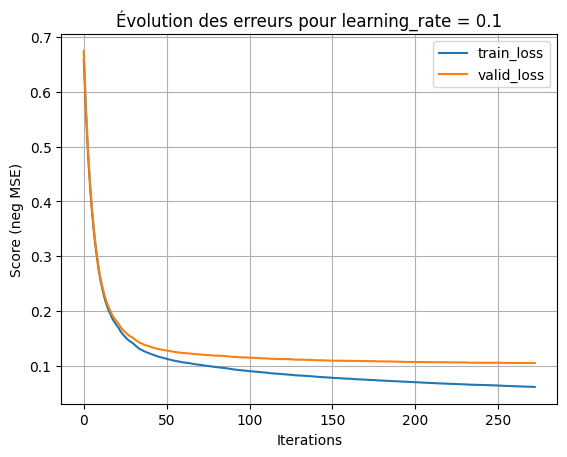

Learning rate: 0.01


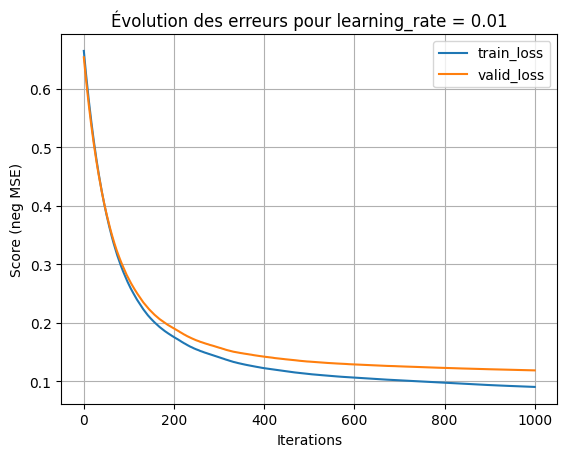

Learning rate: 0.001


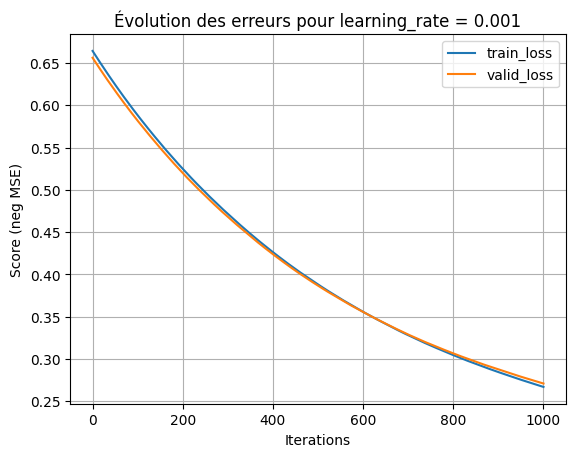

In [144]:
from sklearn.ensemble import HistGradientBoostingRegressor
lr_range = [0.1, 0.01, 0.001]
for i, lr in enumerate(lr_range):
    print(f"Learning rate: {lr}")
    gmb = HistGradientBoostingRegressor(max_iter=1000, max_depth=5, learning_rate=lr, early_stopping=True, validation_fraction=0.2,
                                        scoring="loss")
    gmb.fit(X_train,Y_train)
    # On récupère directement les valeurs, ce sont déjà des erreurs (Loss)
    # On veut la Loss la plus petite possible
    # on fais -1 ici car on veut des courbes qui descendent !
    train_loss = -gmb.train_score_
    valid_loss = -gmb.validation_score_

    iterations = range(len(train_loss))

    plt.plot(iterations, train_loss, label="train_loss")
    plt.plot(iterations, valid_loss, label="valid_loss")
    plt.title(f"Évolution des erreurs pour learning_rate = {lr}")
    plt.xlabel("Iterations")
    plt.ylabel("Score (neg MSE)")
    plt.legend()
    plt.grid(True)
    plt.show()

- Learning Rate = 0.1 : La convergence est extrêmement rapide. On voit que l'early stopping a arrêté l'entraînement aux alentours de la 225ème itération, car le score de validation ne progressait plus.
- Learning Rate = 0.01 : La progression est plus douce. Le modèle a eu besoin des 1000 itérations complètes pour atteindre un niveau de performance similaire au précédent.
- Learning Rate = 0.001 : La pente est très faible. À la 1000ème itération, le modèle est encore loin d'avoir convergé (le score est à environ $-0.27$ contre $-0.1$ pour les autres). Cela confirme qu'un $\eta$ très petit nécessite un nombre d'itérations $L$ beaucoup plus élevé.